
$$
\Large{\textbf{
  Pollutant dispersion: deterministic and stochastic models
  }}
$$

$$
\large{\text{
  Johannes Löppönen, Arvid Hedin, Elis Graipe
  }}
$$
$$
\ \\
\ \\
\ \\
\ \\
\ \\
$$

# Introduction


This project aims to model the dispersion of pollutant particles in air, from combustion. The dispersion can be described using a partial differential equation but in this project the dispersion will be modeled using a stochastic simulation utilizing a random walk for each pollutant particle.



# Approach and method

The mathematical modeling of pollutant dispersion relies on a difference in view models from macroscopic and microscopic perspectives. In the macroscopic viewpoint the pollutant is viewed as a concentration field $C(x, t)$, whose change is determined by the deterministic advection-diffusion equation:

$$\frac{\partial C}{\partial t} + \nabla \cdot (uC) = D\nabla^{2}C$$

This formulation handles the transport process as a continuous flow where the term $\nabla \cdot (uC)$ represents the advective change in position described by the velocity field u, and $D\nabla^{2}C$ describes the diffusion which is governed by the constant D which determines the velocity of the spread. This perspective is deterministic, which gives a predictable description of the pollutants change over time.

For contrast, the microscopic viewpoint instead focuses on the direction of each individual particle X(t). The motion is now instead described by an Itô stochastic differential equation.

$$dX(t) = u(X(t), t)dt + \sqrt{2D}dB(t)$$

In this case the particle's movement is the result of the deterministic advection component and a stochastic diffusion component given by Brownian motion B(t). This results in the path of any single particle being random and unpredictable.

The connection between these two models is provided by the Fokker-Planck equation. This equation says that the probability density function f(x, t), of the particles trajectory satisfies the same PDE as in the macroscopic concentration field.

This leads to the deterministic plume we observe at a large scale being the statistical result of thousands of independent, random particle scale occurances. In this project, we use this link by simulating an sum of particles and using a Monte Carlo approximated Gaussian kernel $\delta_{\epsilon}$ to visualize the continuous concentration field.

$$C(x, t) \approx \frac{1}{N} \sum_{k=1}^{N} \delta_{\epsilon}(x - X^{k}(t))$$

This way of modeling illustrates how a complex process can be split up into simple stochastic rules and applied individual particles. This as a concequence allows for concentration field to be estimated through Monte Carlo simulation rather than direct numerical solving of the PDE.

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1

## Numerical simulation

The Euler-Maruyama method is implemented to solve the stochastic differential equation (SDE) in Task 1. The Euler-Maruyama method is used to numerically integrate the SDE. It integrates the SDE over time for $N$ particles that are independent of each other. 

The iterative method that describes the next position in time for the particles following a starting position $X_0$ is give by

$\mathbf{X}_{n+1} = \mathbf{X}_n + \mathbf{u}h + \sqrt{2Dh}\mathbf{Z}_n, \quad \mathbf{z}_n \sim \mathcal{N}(\mathbf{0}, I_2)$

where $h$ is the time step and $I_2$ is the identity matrix.

In the code the function *euler* implements the above Euler-Maruyama method. It simulates the positions for $N$ particles in the time interval $[0, T]$. The function returns a list of arrays with the positions of the particles at the times specified by the function argument snapshots.

In [164]:
def euler(N, T, h, D, u, num_steps, checkpoints, q):
    X = np.zeros((N, 2))
    particles_per_step = int(q * h) 
    t = np.linspace(0, T, num_steps + 1)

    snapshots = []

    for n in range(num_steps + 1):
        new_particles = np.zeros((particles_per_step, 2))
        X = np.vstack([X, new_particles])
        
        num_active = X.shape[0]
        Z = np.random.randn(num_active, 2)
        X = X + u * h + np.sqrt(2 * D * h) * Z        
        
        if any(np.isclose(t[n], checkpoints)):
            snapshots.append(X.copy())

    return snapshots

Using the implementation of the Euler-Maruyama method in the *euler* function we compute the positions of $N$ number of particles at different times $T$ after 0. The particles originate at the point $\mathbf{X}_0 = (0,0)$ and are visualized in a plot showing how the particles have dispersed by $T$ seconds. The area shown is a rectangle constrained to $x \in [0, 25], \quad y \in [-5, 5]$. The constants and function arguments are defined as follows.

We assume that the dispersion constant and velocity vector are constants and do not depend on time or position. This is not entirely realistic as these are likely to vary in the real world when taking atmospheric conditions into account.
We also assume that the particles exist at $t=0$ and that no new particles are released there after.

In [165]:
# Constants

N = 2000         
T = 60       
h = 0.1         
D = 0.02
epsilon = 0.1

u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

By calling the euler function with four different end times in checkpoints the following snapshots can be plotted from which we can observe how the pollutant particles diffuse.

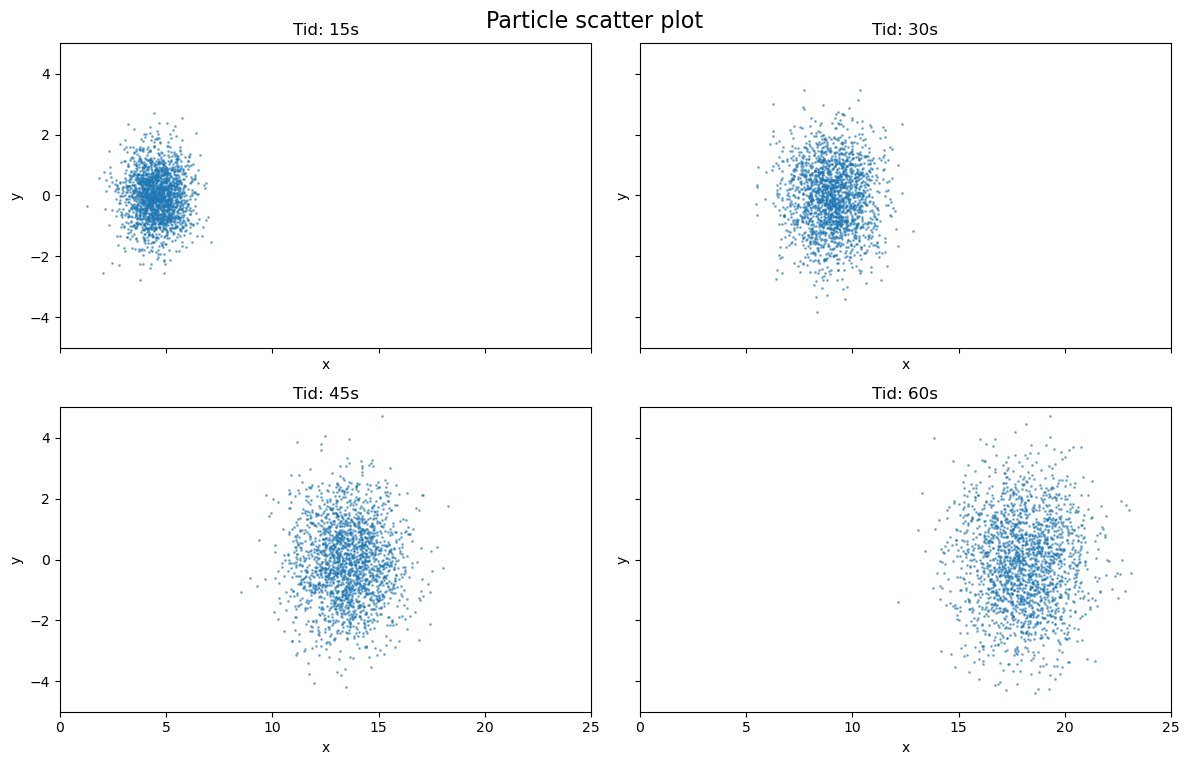

In [ ]:
# Plot

snapshots = euler(N,T,h,D,u,num_steps, checkpoints, 0) # No source term
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.suptitle('Particle Scatter Plot', fontsize=16, y=0.95)
plt.tight_layout()

plt.show()

The diffusion of the pollutant particles is quite obvious upon inspection of the above plot. The particles disperse outward from the starting point but it can also be observed that the particles have a common drift in the positive x-direction. This is because the velocity vector $\mathbf{u}$ applies to all particles. 

The simulation is good at showing the macroscopic changes in pollutant distribution but it does not give any information about the movement of individual particles.

# Task 2

For the second task the purpose is to compute and visualize the concentration of pollutant particles in the same rectangular domain as the in previous task.

The concentration of pollutant particles is performed using the Monte Carlo method on the following formula
$C(\mathbf{x},t) \approx \frac{1}{N} \sum_{k=1}^N \delta_{\epsilon} (\mathbf{x}-\mathbf{X}^k(t))$
where $\mathbf{X}$ is a random variable $\mathbf{x}$ is the current position of a particle and $\delta_\epsilon$ is the Dirac delta distribution.

In the code we create an approximation of the Dirac delta distribution to avoid problems with infinity. This approximation is provided by the function *delta_eps*.

The Monte Carlo method described above is implemented in the function *compute_concentration*. This function takes in the computed particle distribution snapshots, computed by the *euler* function, runs the Monte Carlo simulations and returns an array with the concentrations at the coordinates provided by the function arguments for each snapshot (point in time).

One assumption that has been made in this computation is that the number of particles is big enough for the Monte Carlo method to give a sufficiently good result as it is not possible to run the method more than $N$ times.

In [167]:
def delta_eps(dist, epsilon):
    fac = 1/(2*np.pi*epsilon**2)
    e = np.exp(-dist / (2*epsilon**2))
    return fac * e

def compute_concentration(x_grid, y_grid, snapshot, epsilon):
    N = snapshot.shape[0] #Amount of particles at time t
    C = np.zeros(x_grid.shape)

    for k in range(N):
        dist = ((x_grid - snapshot[k,0])**2 + (y_grid - snapshot[k,1])**2)
        C += delta_eps(dist, epsilon)

    return C / N

Using the results from the previous task we can now plot the concentration of pollutant particles in the same domain from *compute_concentration* using a surface contour plot.

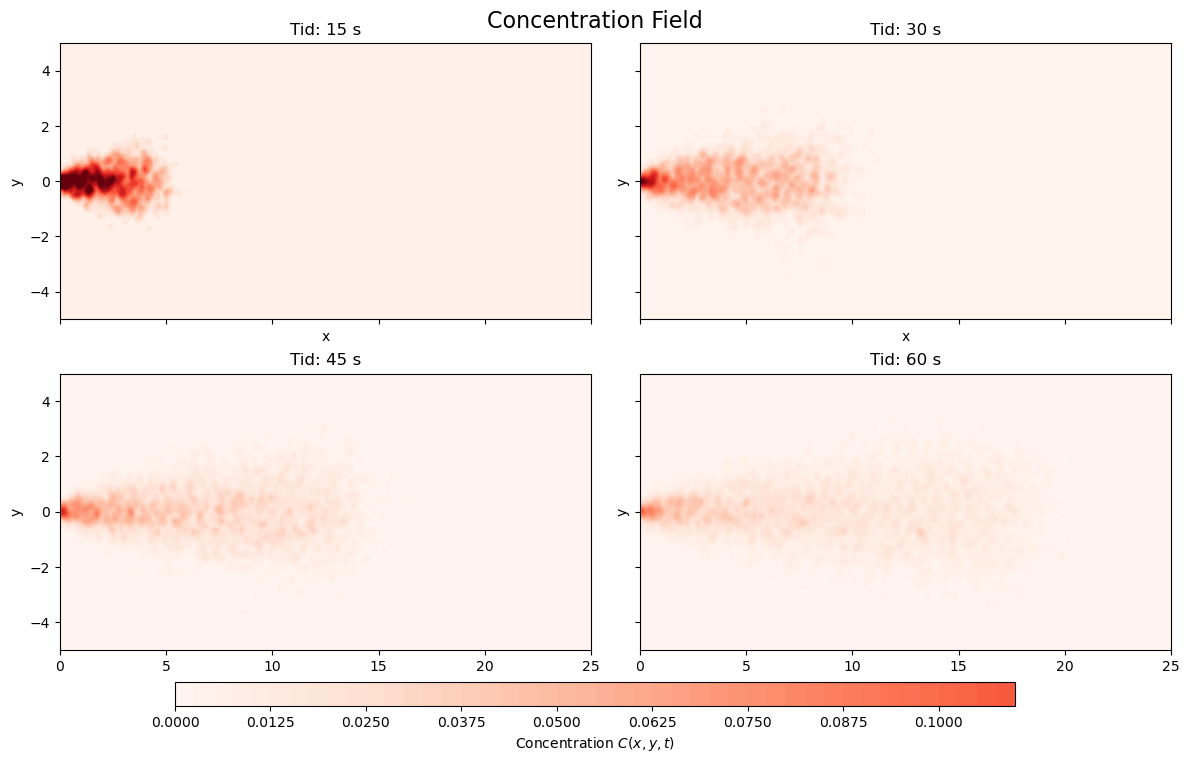

In [175]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

for i in range(len(snapshots)): # Snapshots is the results from Task 1
    X = snapshots[i]
    C = compute_concentration(x_grid, y_grid, X, epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.suptitle('Concentration Field', fontsize=16, y=0.95)
plt.tight_layout()

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Concentration $C(x,y,t)$')

plt.show()

This plot shows that the dispersion of the pollutant particles results in the concentration of pollutant particles decreasing. It also shows that the concentration, similarly to the particles, moves downwind because of the velocity vector $\mathbf{u}$.

# Task 3

A more realistic simulation of pollutant dispersion often includes a source term which takes into account that the pollutants often are released continuously from a chimney for example.

The function *euler* takes this into account by including an argument for a source term and adds the amount of pollutant particles that are released in between each time step during each iteration.

To study how the pollutant particles and their concentration behaves when they are continuously released we simply need to re-run the simulations from earlier with new constants and function arguments.

The model assumes a constant release rate from the source as well as constant dispersion and initial velocity.

In [169]:
# Constants
N = 0         
T = 60       
h = 0.1         
D = 0.02     
Q = 100    
u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

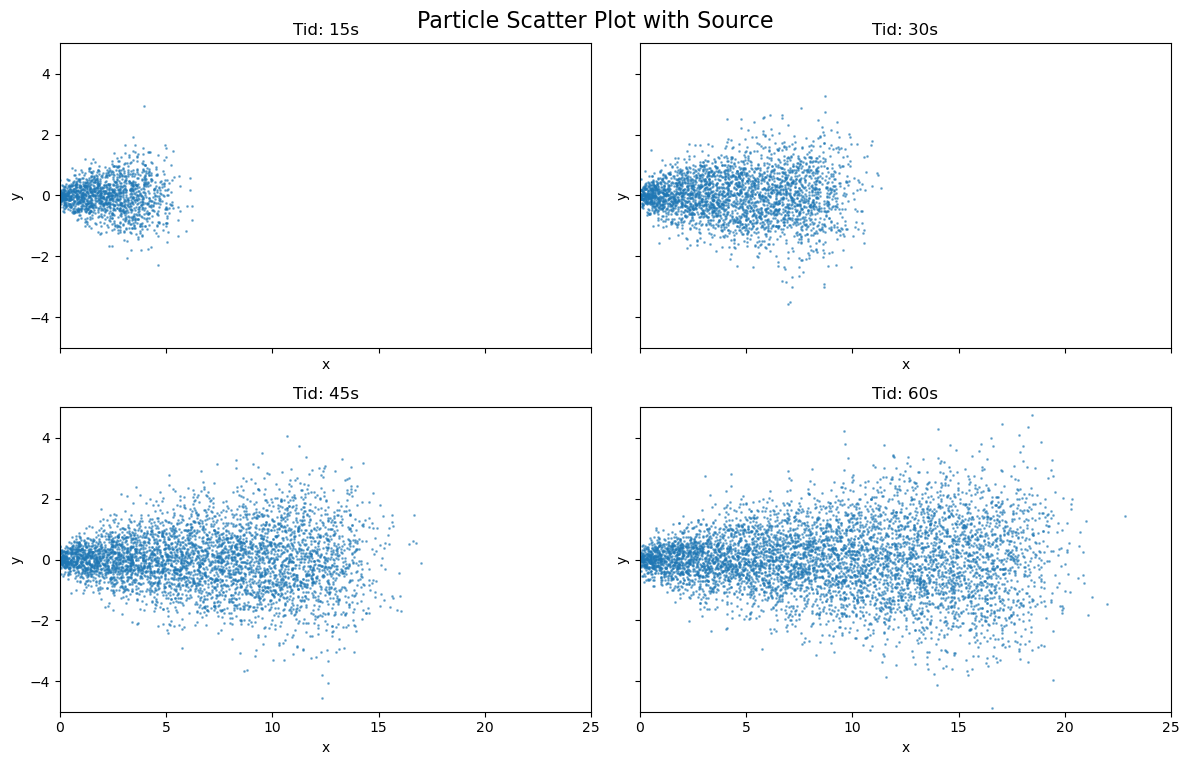

In [173]:
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,Q)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.suptitle('Particle Scatter Plot with Source', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

The result of adding the source term is that the amount of pollutant particles increases over time. From inspection it seems that the amount of particles released is about in balance with the amount that is dispersed away.

Similarly, the concentration field can be plotted with the source term.

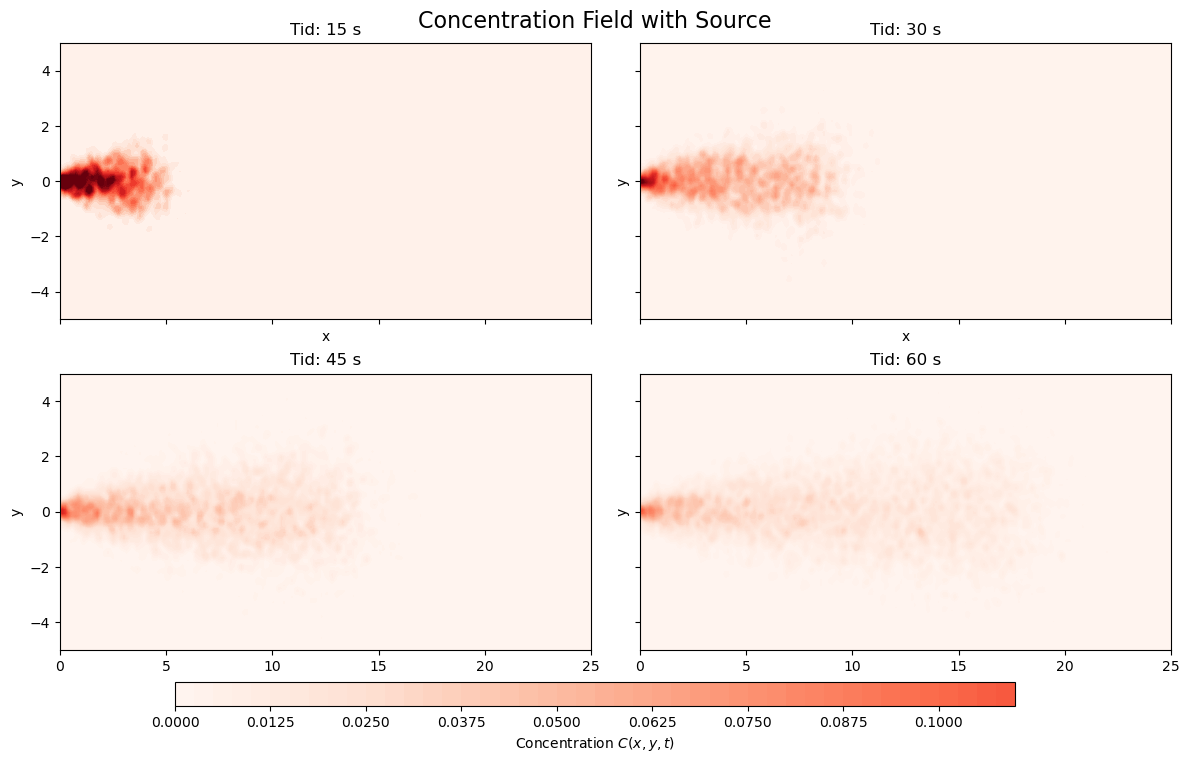

In [174]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

for i in range(len(snapshots)):
    C = compute_concentration(x_grid, y_grid, snapshots[i], epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.suptitle('Concentration Field with Source', fontsize=16, y=0.95)
plt.tight_layout()

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Concentration $C(x,y,t)$')

plt.show()

The plot of the concentration field with the source term shows that there seems to be a tight concentration of pollutant particles close to the origin at $t=0$ and that once they get dispersed away the concentration in the plot's domain evens out with the highest concentration at the origin and smoothly decreasing from there.

# Results

## Without Source Term

## With Source Term

# Discussion


## Model Parameters
The simulation results are heavily influenced by the parameters D, u, and Q, each representing a distinct physical mechanism in the transport of pollutants.

### Diffusion Coefficient (D)
This parameter represents the molecular agitation and random motion that causes particles to spread away from each other. A value of zero would result in no spreading. The particles would simply follow the streamlines of the velocity field as a single point. As D increases, the "particle cloud" expands more rapidly, leading to a lower concentration as the pollutant is diluted over a larger area.

### Velocity (u)
The velocity field u represents the deterministic transport of the pollutant by the mean fluid flow, such as wind or water currents. While D causes the cloud to grow in size, u determines the trajectory of the cloud's center of mass. 

### Emission Rate (Q)
The parameter Q defines the emission rate of the pollutant source. In Tasks 1 and 2, Q is effectively zero after t=0 because we modeled an initial single-release scenario where N=2000 particles were released simultaneously. In Task 3, a non-zero Q represents a continuous source, such as an exhaust pipe or chimney. This creates a steady-state output where the highest concentrations remain  at the source location. 


## Deterministic and Stochastic Approaches
The project highlights two complementary viewpoints for modeling the same physical process: the macroscopic Eulerian viewpoint and the microscopic Lagrangian viewpoint.

### The Eulerian Viewpoint (PDE): 
The advection diffusion equation describes the evolution of the concentration field C(x,t) as a continuous distribution. This approach is mathematically rigorous and provides a smooth representation of the pollutant density, but solving the PDE directly can be computationally demanding in complex 3D geometries.


### The Lagrangian Viewpoint (SDE): 
The stochastic approach focuses on the trajectories of individual particles X(t) using Itô stochastic differential equations. By simulating a large number of independent realizations (N), we can estimate the concentration field using a Monte Carlo method.


### Comparison and Reflections:

Consistency: The two models are linked via the Fokker-Planck equation, which shows that the probability density function (pdf) of the random particle motion satisfies the same equation as the physical concentration field.


Implementation: The stochastic method (Euler-Maruyama) is often easier to implement for complex scenarios, such as the continuous injection of new particles in Task 3. It does not require a complex mesh for the solver, though it does require a high N to reduce statistical noise.


Smoothing: A key challenge in the stochastic approach is the choice of the smoothing parameter ϵ. If ϵ is too small, the reconstructed concentration field appears "noisy" or "spiky", if it is too large, the spatial resolution is lost, and the concentration peaks are artificially flattened.

## Simulation Results Task 2

The simulation results show how the pollutants movement and shape are determined by the results of advection and diffusion. The advection effect from u is clearly visible how it acts as a transport mechanism that pushes the entire particle cloud along the x-axis. This represents the physical flow of the surrounding matter carrying the pollutant mass away from its starting point. 

While advection moves the cloud, diffusion is what causes it to spread out and expand in all directions. As the simulation time increases the plume becomes visibly wider and the peak concentration decreases because the same amount of pollutant gets spread over a larger area.

Experiments with different constant values reveal how each factor influences the clouds evolution. Increasing the velocity u causes the cloud to travel further across the domain in the same amount of time, but it does not change how fast the cloud grows. On the other hand, increasing the diffusion coefficient D makes the cloud expand much faster, making it look larger and more diluted. The smoothing parameter $\epsilon$ also affects the results where a smaller value provides a sharper view of the concentration and vice versa.

## Difference Between Task 1,2 and Task 3

The most striking difference is the visual structure of the particle cloud.
In task 1 and 2 all particles are released simultaneously at X = 0,0 and t = 0. And here it is only the model parameter D that is affecting the particle cloud, so the particles moves out in all directions from 0,0. 

In task 3 the particles are injected at a constant rate Q=100 per second. This results in a "plume" that stretches from the source at 0,0 all the way to the leading edge of the flow. Because new particles are added at every time step t, the space between the source and the front of the plume is constantly filled. This leads to a particle cloud that is not round but is more cone formed. 
